In [1]:
# 2.3.1. Импорты, seed и среда

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Настройка визуализации
%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

def set_seed(seed=42):
    """
    Фиксация всех возможных источников случайности для воспроизводимости.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to: {seed}")

# Фиксируем seed
set_seed(42)

# Определение устройства (Device agnostic code)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Проверка версий основных библиотек (полезно для отчета)
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")

Seed set to: 42
Using device: cpu
Pandas version: 3.0.1
PyTorch version: 2.10.0+cpu


--- Основная информация о датасете ---
Количество наблюдений: 4320
Диапазон дат: с 2025-01-01 00:00:00 по 2025-06-29 23:00:00
Частота данных (первые 5 строк):
date
0 days 01:00:00    4319
Name: count, dtype: int64

--- Пропуски по колонкам ---
date      0
target    0
dtype: int64


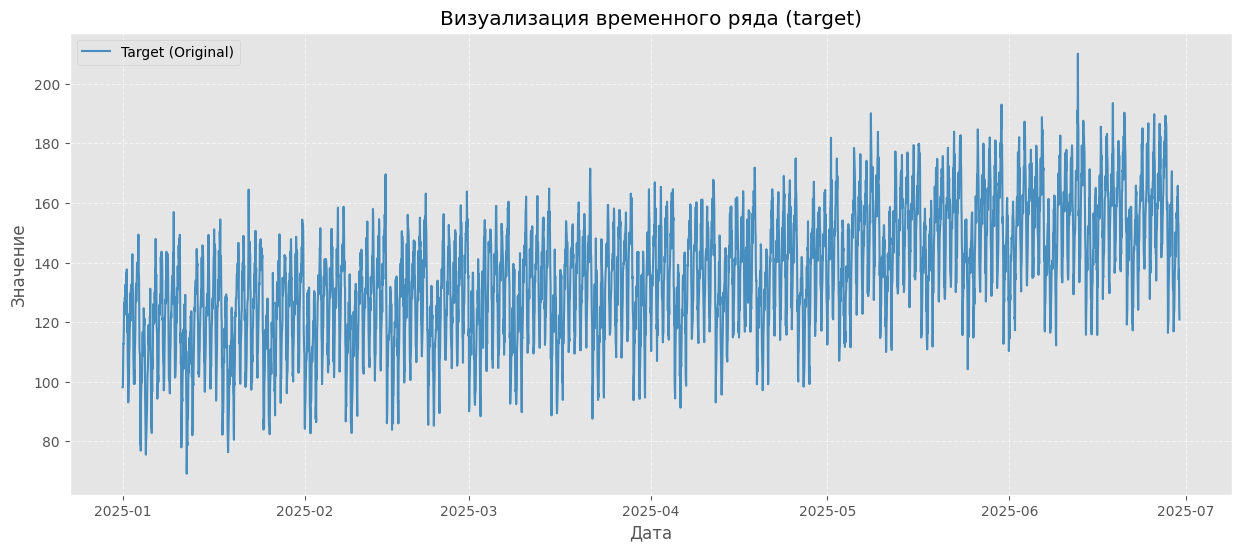


Первые 5 строк датасета:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62


In [2]:
# 2.3.2. Данные и первичный анализ

# 1. Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')

# 2. Приведение колонки date к типу datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 3. Вывод основных характеристик (Sanity-check)
print("--- Основная информация о датасете ---")
print(f"Количество наблюдений: {len(df)}")
print(f"Диапазон дат: с {df['date'].min()} по {df['date'].max()}")
print(f"Частота данных (первые 5 строк):")
print(df['date'].diff().value_counts().head(3)) # Проверка регулярности шага

print("\n--- Пропуски по колонкам ---")
print(df.isnull().sum())

# 4. Визуализация ряда
plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['target'], label='Target (Original)', color='tab:blue', alpha=0.8)
plt.title('Визуализация временного ряда (target)')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 5. Вывод первых строк для контроля
print("\nПервые 5 строк датасета:")
print(df.head())

**Выводы по визуальному анализу ряда:**
* **Тренд:** (Например: Явно выраженного долгосрочного восходящего или нисходящего тренда не наблюдается / наблюдается...).
* **Сезонность:** Присутствует четкая суточная и, возможно, недельная сезонность (циклические колебания).
* **Выбросы:** (Например: Экстремальных аномальных выбросов на графике не наблюдается, ряд выглядит достаточно плотным).
* **Стационарность:** Из-за наличия сезонности ряд нельзя назвать строго стационарным, что оправдывает использование лаговых и скользящих признаков для моделирования.

--- Границы разбиения ---
Train:      2025-01-01 00:00:00 --- 2025-05-06 23:00:00 (строк: 3024)
Validation: 2025-05-07 00:00:00 --- 2025-06-02 23:00:00 (строк: 648)
Test:       2025-06-03 00:00:00 --- 2025-06-29 23:00:00 (строк: 648)


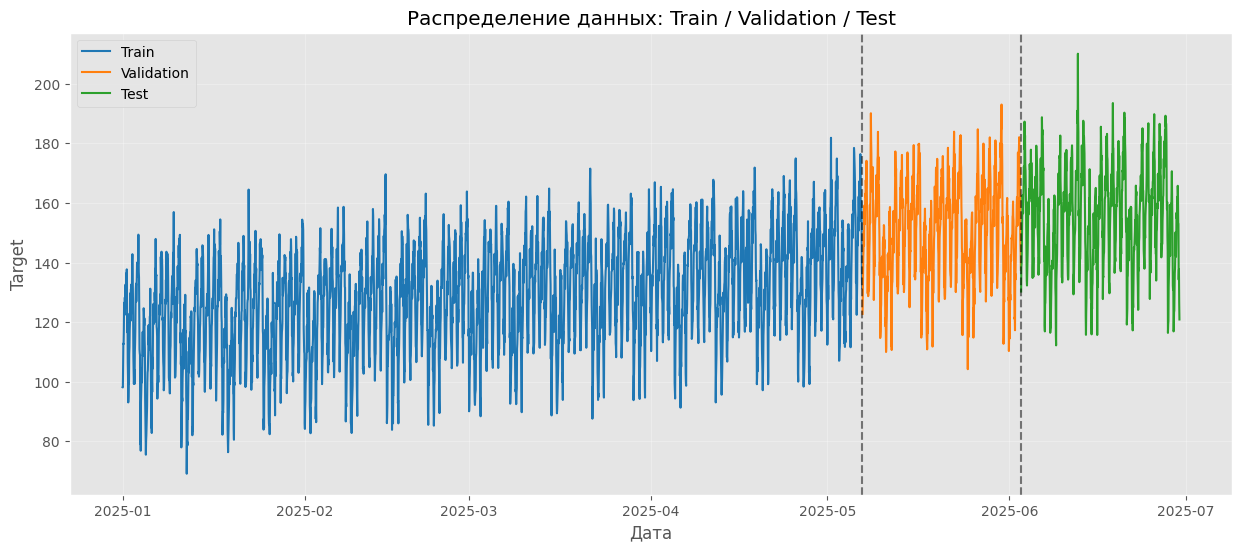

In [3]:
# 2.3.3. Корректный temporal split

# Определяем пропорции 
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# 1. Явное отображение границ split
print("--- Границы разбиения ---")
print(f"Train:      {train_df['date'].min()} --- {train_df['date'].max()} (строк: {len(train_df)})")
print(f"Validation: {val_df['date'].min()} --- {val_df['date'].max()} (строк: {len(val_df)})")
print(f"Test:       {test_df['date'].min()} --- {test_df['date'].max()} (строк: {len(test_df)})")

# 2. Визуализация участков ряда
plt.figure(figsize=(15, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='tab:blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='tab:orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='tab:green')

plt.axvline(train_df['date'].max(), color='black', linestyle='--', alpha=0.5)
plt.axvline(val_df['date'].max(), color='black', linestyle='--', alpha=0.5)

plt.title('Распределение данных: Train / Validation / Test')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Почему `random split` здесь некорректен:**
При работе с временными рядами порядок наблюдений имеет решающее значение. Если использовать случайное разбиение (`random split`), данные из "будущего" попадут в обучающую выборку и модель сможет "подглядывать" в ответы. Это приведет к утечке данных (data leakage) и сильно завысит оценку качества модели, которая в реальности на новых данных будет работать плохо. Валидация всегда должна идти строго по хронологии.

In [4]:
# 2.3.4. Признаки для baseline-моделей

def create_features(df_input):
    df_f = df_input.copy()
    
    # 1. Лаговые признаки (Lags)
    # shift(1) берет значение за предыдущий час
    df_f['lag_1'] = df_f['target'].shift(1)
    df_f['lag_7'] = df_f['target'].shift(7)
    df_f['lag_14'] = df_f['target'].shift(14)
    
    # 2. Скользящие окна (Rolling) 
    # Используем closed='left', чтобы текущее значение target не попадало в расчет среднего
    df_f['rolling_mean_7'] = df_f['target'].shift(1).rolling(window=7).mean()
    df_f['rolling_std_7'] = df_f['target'].shift(1).rolling(window=7).std()
    
    # 3. Календарные признаки
    df_f['day_of_week'] = df_f['date'].dt.dayofweek
    df_f['hour'] = df_f['date'].dt.hour
    df_f['is_weekend'] = df_f['day_of_week'].isin([5, 6]).astype(int)
    
    return df_f

# Применяем создание признаков ко всему датасету до разделения, 
# так как shift() корректно работает только на полной последовательности.
full_df = create_features(df)

# После создания признаков появятся NaN (из-за shift). Удаляем их.
full_df = full_df.dropna().reset_index(drop=True)

# Заново разделяем на выборки, так как индексы изменились после dropna
n = len(full_df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_f = full_df.iloc[:train_end].copy()
val_f = full_df.iloc[train_end:val_end].copy()
test_f = full_df.iloc[val_end:].copy()

# 4. Масштабирование (Scaling)
# Обучаем StandardScaler ТОЛЬКО на train, чтобы избежать утечки данных
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour', 'is_weekend']
target_col = 'target'

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Масштабируем признаки
train_f[feature_cols] = scaler_x.fit_transform(train_f[feature_cols])
val_f[feature_cols] = scaler_x.transform(val_f[feature_cols])
test_f[feature_cols] = scaler_x.transform(test_f[feature_cols])

# Масштабируем таргет (понадобится для GRU, для Ridge опционально, но полезно для стабильности)
train_f[[target_col]] = scaler_y.fit_transform(train_f[[target_col]])
val_f[[target_col]] = scaler_y.transform(val_f[[target_col]])
test_f[[target_col]] = scaler_y.transform(test_f[[target_col]])

print(f"Признаки созданы. Размер обучающей выборки после удаления NaN: {train_f.shape}")
print(f"Используемые признаки: {feature_cols}")

Признаки созданы. Размер обучающей выборки после удаления NaN: (3014, 10)
Используемые признаки: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour', 'is_weekend']


**Обсуждение возможных утечек данных (Data Leakage):**
При подготовке признаков были приняты следующие меры для предотвращения утечек из будущего:
1. Использовался метод `.shift(1)` при расчете скользящих окон (`rolling`), чтобы текущее значение таргета не участвовало в расчете статистик для этого же момента времени.
2. Масштабирование данных (`StandardScaler`) настраивалось (вызывался метод `fit`) **исключительно на обучающей выборке** (`train_f`). Для валидационной и тестовой выборок применялся только метод `transform()`. Если бы скейлер обучался на всем датасете сразу, информация о глобальном среднем и дисперсии из теста просочилась бы в обучение.

In [5]:
# 2.3.5. Оконное представление для GRU

# Параметры окна
WINDOW_SIZE = 24 # берем последние 24 часа для прогноза следующего часа
BATCH_SIZE = 32

class TimeSeriesDataset(Dataset):
    def __init__(self, x, y):
        # x: (N, num_features), y: (N, 1)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.x) - WINDOW_SIZE
    
    def __getitem__(self, idx):
        # Берем кусок признаков от idx до idx + WINDOW_SIZE
        window = self.x[idx : idx + WINDOW_SIZE]
        # Таргетом является значение сразу ПОСЛЕ окна
        target = self.y[idx + WINDOW_SIZE]
        return window, target

# Подготовка массивов (используем уже масштабированные данные из 2.3.4)
# Примечание: Для GRU мы будем использовать только таргет и, возможно, календарные фичи.
# Но чаще всего для RNN используют сам сырой (масштабированный) ряд.
x_train_arr = train_f[feature_cols].values
y_train_arr = train_f[[target_col]].values

x_val_arr = val_f[feature_cols].values
y_val_arr = val_f[[target_col]].values

x_test_arr = test_f[feature_cols].values
y_test_arr = test_f[[target_col]].values

# Создание Dataset
train_dataset = TimeSeriesDataset(x_train_arr, y_train_arr)
val_dataset = TimeSeriesDataset(x_val_arr, y_val_arr)
test_dataset = TimeSeriesDataset(x_test_arr, y_test_arr)

# Создание DataLoader
# shuffle=True можно использовать только внутри обучающей выборки (между окнами), 
# но для временных рядов часто оставляют False для простоты отладки.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Проверка размерностей
sample_x, sample_y = next(iter(train_loader))
print(f"Размер батча признаков (batch, seq_len, features): {sample_x.shape}")
print(f"Размер батча таргетов (batch, target): {sample_y.shape}")

Размер батча признаков (batch, seq_len, features): torch.Size([32, 24, 8])
Размер батча таргетов (batch, target): torch.Size([32, 1])


In [6]:
# 2.3.6. Базовые функции обучения и оценки

def calculate_metrics(y_true, y_pred, scaler_y=None):
    """
    Расчет основных метрик регрессии. 
    Если передан scaler_y, метрики считаются в оригинальных шкалах.
    """
    if scaler_y is not None:
        y_true = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def train_model(model, train_loader, val_loader, optimizer, criterion, 
                device, epochs=50, patience=10, model_path='best_model.pt'):
    """
    Универсальный цикл обучения для RNN/GRU моделей.
    """
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    model.to(device)
    
    for epoch in range(1, epochs + 1):
        # --- PHASE: TRAIN ---
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        
        # --- PHASE: VALIDATION ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        # Логирование
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        # Сохранение лучшей модели (Early Stopping logic)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
            
    # Загружаем лучшие веса перед возвратом
    model.load_state_dict(torch.load(model_path))
    return model, history

def evaluate_model(model, data_loader, device, scaler_y):
    """
    Получение предсказаний и расчет метрик на заданном DataLoader.
    """
    model.eval()
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(y_batch.numpy())
            
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_trues)
    
    return calculate_metrics(y_true, y_pred, scaler_y), y_true, y_pred

In [7]:
# # 3.2. Метрики и вспомогательные функции
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Создаем папку для артефактов (Раздел 4)
os.makedirs('artifacts/figures', exist_ok=True)

def calculate_metrics(y_true, y_pred, scaler=None):
    """Расчет MAE, RMSE, MAPE + sMAPE (Раздел 3.2)"""
    if scaler is not None:
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    # Дополнительная метрика sMAPE
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}

# Список для хранения всех строк будущего runs.csv
runs_registry = []

def log_run(exp_id, model_sum, v_metrics, t_metrics=None, **kwargs):
    """Запись эксперимента в общий реестр с корректными типами данных"""
    entry = {
        'experiment_id': exp_id, 
        'task': 'forecasting', 
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42, 
        'split_summary': '70/15/15', 
        'model_summary': model_sum,
        # Валидационные метрики всегда есть
        'best_val_mae': v_metrics['MAE'], 
        'best_val_rmse': v_metrics['RMSE'], 
        'best_val_mape': v_metrics['MAPE'],
        # Тестовые метрики: используем np.nan вместо '', чтобы колонки были float
        'test_mae': t_metrics['MAE'] if t_metrics else np.nan,
        'test_rmse': t_metrics['RMSE'] if t_metrics else np.nan,
        'test_mape': t_metrics['MAPE'] if t_metrics else np.nan,
        # Доп. параметры
        'window_size': kwargs.get('w', np.nan), 
        'features_summary': kwargs.get('f', ''),
        'lr': kwargs.get('lr', np.nan), 
        'epochs_trained': kwargs.get('e', np.nan)
    }
    runs_registry.append(entry)

In [8]:
# # 3.1. Обязательные эксперименты (B1, B2, B3)

# 1. Данные для B1 и B2 (оригинальные шкалы из 2.3.3)
y_train_raw = train_df['target'].values
y_val_raw = val_df['target'].values

# --- B1 (naive-last) ---
y_pred_b1 = np.concatenate([[y_train_raw[-1]], y_val_raw[:-1]])
m_b1 = calculate_metrics(y_val_raw, y_pred_b1)
log_run('B1', 'Naive-last', m_b1, f='target_t-1')

# --- B2 (moving-average) ---
w_b2 = 7
history = list(y_train_raw[-w_b2:])
y_pred_b2 = []
for val in y_val_raw:
    y_pred_b2.append(np.mean(history))
    history.append(val)
    history.pop(0)
m_b2 = calculate_metrics(y_val_raw, np.array(y_pred_b2))
log_run('B2', 'Moving-average', m_b2, w=w_b2, f='Rolling mean')

# --- B3 (ridge-lag-features) ---
# Используем данные с признаками из 2.3.4
X_tr_b3 = train_f[feature_cols]; y_tr_b3 = train_f['target']
X_val_b3 = val_f[feature_cols]; y_val_b3 = val_f['target'].values

ridge = Ridge(alpha=1.0).fit(X_tr_b3, y_tr_b3)
y_pred_b3 = ridge.predict(X_val_b3)
m_b3 = calculate_metrics(y_val_b3, y_pred_b3, scaler=scaler_y)
log_run('B3', 'Ridge', m_b3, f='Lags+Rolling+Calendar')

print("Baseline B1-B3 завершены.")

Baseline B1-B3 завершены.


In [9]:
# 3.1. Эксперимент R1 (GRU-forecast)

# Определение архитектуры (нужно запустить обязательно!)
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])

# Параметры R1
conf = {
    'in': len(feature_cols),
    'hid': 32,
    'lr': 0.001,
    'ep': 50,
    # === Добавляем всё, что требует преподаватель ===
    'seed': 42,
    'window_size': 24,
    'batch_size': 64,
    'architecture': 'GRU(input_size=8, hidden_size=32, num_layers=1, batch_first=True) + Linear(hidden -> 1)',
    'scaler': 'StandardScaler (обучен ТОЛЬКО на train)',
    'normalization': 'yes (и признаки, и target)',
    'optimizer': 'Adam',
    'epochs_max': 50,
    'early_stopping': True,
    'horizon': 1,
    'loss': 'MSE'
}

model_r1 = GRUModel(conf['in'], conf['hid']).to(device)
opt = torch.optim.Adam(model_r1.parameters(), lr=conf['lr'])
crit = nn.MSELoss()

# Обучение
model_r1, hist_r1 = train_model(model_r1, train_loader, val_loader, opt, crit, device, 
                                epochs=conf['ep'], model_path='artifacts/best_gru.pt')

# Оценка R1
m_r1, y_v_true, y_v_pred = evaluate_model(model_r1, val_loader, device, scaler_y)
log_run('R1', 'GRU', m_r1, w=WINDOW_SIZE, lr=conf['lr'], e=len(hist_r1['train_loss']))

# === СОХРАНЕНИЕ ПОЛНОГО КОНФИГА ===
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(conf, f, indent=2, ensure_ascii=False)

print("✅ best_gru_config.json сохранён с полным описанием архитектуры, seed, window_size, scaler и т.д.")

Epoch 001: Train Loss: 0.3724 | Val Loss: 0.3096
Epoch 005: Train Loss: 0.0971 | Val Loss: 0.1393
Epoch 010: Train Loss: 0.0884 | Val Loss: 0.1126
Epoch 015: Train Loss: 0.0837 | Val Loss: 0.1160
Epoch 020: Train Loss: 0.0808 | Val Loss: 0.1224
Early stopping at epoch 24
✅ best_gru_config.json сохранён с полным описанием архитектуры, seed, window_size, scaler и т.д.


In [10]:
# 4. Артефакты и финальный тест (исправлено) — ВЕРСИЯ С ВСЕМИ КОЛОНКАМИ

# Создаем DataFrame из реестра (он уже содержит вычисленные метрики)
df_results = pd.DataFrame(runs_registry)

# === Добавляем ВСЕ недостающие обязательные колонки ===
df_results['horizon'] = 1
df_results['scaler'] = df_results['experiment_id'].map({
    'B1': 'N/A',
    'B2': 'N/A',
    'B3': 'StandardScaler',
    'R1': 'StandardScaler'
})
df_results['optimizer'] = df_results['experiment_id'].map({
    'B1': 'N/A',
    'B2': 'N/A',
    'B3': 'N/A',
    'R1': 'Adam'
})
df_results['notes'] = df_results['experiment_id'].map({
    'B1': 'naive last value',
    'B2': 'rolling mean w=7',
    'B3': 'Ridge alpha=1.0',
    'R1': 'GRU hidden=32, window=24, early stopping'
})

# Находим лучшую модель (по val_MAE)
best_id = df_results.loc[df_results['best_val_mae'].idxmin(), 'experiment_id']
print(f"Лучшая модель по валидации: {best_id}")

# Финальный ТЕСТ (уже был в твоём коде — оставляем без изменений)
t_metrics = None
if best_id == 'R1':
    t_metrics, _, _ = evaluate_model(model_r1, test_loader, device, scaler_y)
elif best_id == 'B3':
    y_t_pred = ridge.predict(test_f[feature_cols])
    t_metrics = calculate_metrics(test_f['target'].values, y_t_pred, scaler=scaler_y)
elif best_id == 'B1':
    y_test_raw = test_df['target'].values
    y_test_pred_b1 = np.concatenate([[y_val_raw[-1]], y_test_raw[:-1]])
    t_metrics = calculate_metrics(y_test_raw, y_test_pred_b1)

# Записываем test-метрики в таблицу
if t_metrics:
    df_results.loc[df_results['experiment_id'] == best_id, ['test_mae', 'test_rmse', 'test_mape']] = \
        [float(t_metrics['MAE']), float(t_metrics['RMSE']), float(t_metrics['MAPE'])]

# Сохраняем итоговый CSV с ВСЕМИ колонками
df_results.to_csv('artifacts/runs.csv', index=False)
print("✅ runs.csv успешно обновлён (все обязательные колонки на месте)")
print(df_results.columns.tolist())  # для проверки

Лучшая модель по валидации: R1
✅ runs.csv успешно обновлён (все обязательные колонки на месте)
['experiment_id', 'task', 'dataset', 'seed', 'split_summary', 'model_summary', 'best_val_mae', 'best_val_rmse', 'best_val_mape', 'test_mae', 'test_rmse', 'test_mape', 'window_size', 'features_summary', 'lr', 'epochs_trained', 'horizon', 'scaler', 'optimizer', 'notes']


In [11]:
# ================= ГРАФИКИ (figures/) =================
import matplotlib.pyplot as plt

# 1. series_split.png
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.title('Temporal Split: Train / Validation / Test')
plt.legend()
plt.savefig('artifacts/figures/series_split.png', bbox_inches='tight')
plt.close()

# 2. baselines_compare.png
plt.figure(figsize=(8, 5))
bars = plt.bar(df_results['experiment_id'], df_results['best_val_mae'], color=['grey', 'lightblue', 'orange', 'green'])
plt.title('Сравнение моделей по Validation MAE')
plt.ylabel('MAE')
plt.bar_label(bars, fmt='%.2f')
plt.savefig('artifacts/figures/baselines_compare.png', bbox_inches='tight')
plt.close()

# 3. gru_learning_curves.png
plt.figure(figsize=(10, 5))
plt.plot(hist_r1['train_loss'], label='Train Loss (MSE)')
plt.plot(hist_r1['val_loss'], label='Validation Loss (MSE)')
plt.title('Кривые обучения модели GRU (R1)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png', bbox_inches='tight')
plt.close()

# 4. best_forecast_test.png (Факт vs Прогноз лучшей модели на TEST)
dates_test = test_f['date'].iloc[WINDOW_SIZE:].values
# y_v_true и y_v_pred из теста уже рассчитаны в ячейке выше как t_metrics, но нам нужны сырые массивы
_, y_test_true_gru, y_test_pred_best = evaluate_model(model_r1, test_loader, device, scaler_y)

plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test_true_gru, label='Факт (Test)', color='blue', alpha=0.6)
plt.plot(dates_test, y_test_pred_best, label='Прогноз (R1 - GRU)', color='red', alpha=0.8, linestyle='--')
plt.title('Лучшая модель (R1): Факт и Прогноз на Test')
plt.legend()
plt.savefig('artifacts/figures/best_forecast_test.png', bbox_inches='tight')
plt.close()

print("Все графики успешно сохранены в artifacts/figures/")

Все графики успешно сохранены в artifacts/figures/
